# 03 — Full-Year Mobility EDA

Role: primary mobility analysis for the full year. Demand by hour, weekday, and month;
trip distance, duration, and speed behavior; and relationships among mobility
variables.

Architecture: each month is loaded, cleaned, aggregated, and discarded in a single
pass, so the full year is never held in memory as one table. A second pass runs only
for the two metrics that need a global threshold computed in the first pass.

Note on year: YEAR = 2025.

In [1]:
import sys
sys.path.append('../src')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

from scipy import stats
from folium.plugins import HeatMap
from data_loader import load_month, load_zone_shapes
from preprocessing import clean_trips
from feature_engineering import add_features
from visualization import plot_bar, plot_heatmap, save_fig

pd.set_option('display.max_columns', None)
YEAR = 2025
MONTHS = range(1, 13)
OUT_DIR = '../data/outputs'
import os
os.makedirs(OUT_DIR, exist_ok=True)

DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ALL_COLS = ['trip_distance', 'trip_duration_min', 'average_speed_mph', 'fare_amount', 'tip_amount', 'total_amount']
MV_COLS = ['trip_distance', 'trip_duration_min', 'average_speed_mph']  # subset of ALL_COLS, sliced from the same moments

SAMPLE_ROWS_PER_MONTH = 15_000   # bounded scatter/residual sample -> capped ~180k rows for the full year
BUCKET_SAMPLE_PER_MONTH = 5_000  # bounded per-bucket sample for the Pass-2 significance test

# A handful of records carry implausible trip_distance values (tens of thousands of miles -- not physically possible for a NYC taxi trip). 
#Left unfiltered, these dominate the streaming moment sums (Pearson/covariance are highly outlier-sensitive)
# and collapse every correlation toward zero even when the true relationship is strong.

# Used only to EXCLUDE rows from moment ESTIMATION (Section 11/12); Pass 2 still EVALUATES every row, including these, 
# against the resulting clean mean/covariance, so extreme trips are still correctly flagged as outliers rather than hidden from detection.
MAX_PLAUSIBLE_DISTANCE_MI = 100.0

# Near-zero (but still > 0) trip_distance values inflate fare_per_mile toward infinity from a tiny denominator, 
# without reflecting a real per-mile rate. Used only when building the Section 14b fare-per-mile buckets.
MIN_DISTANCE_FOR_FPM_MI = 0.1

HIST_RANGES = {
    'trip_distance': (0.0, 100.0, 1000),      # 0.1 mi resolution
    'trip_duration_min': (0.0, 300.0, 600),   # 0.5 min resolution
    'average_speed_mph': (0.0, 100.0, 500),   # 0.2 mph resolution
    'fare_amount': (0.0, 300.0, 600),         # 0.5 dollar resolution
}

## 1. Streaming Helper Functions
Reusable functions for histogram accumulation, percentile lookup, and streaming
mean/covariance/correlation. No external dependency beyond NumPy and pandas.

In [2]:
def update_hist(acc, col, values):
    """Accumulate a fixed-bin histogram for one column. Clips out-of-range values into
    the boundary bin so counts are never dropped."""
    lo, hi, n_bins = HIST_RANGES[col]
    edges = acc['edges'][col]
    clipped = np.clip(values, lo, hi)
    counts, _ = np.histogram(clipped, bins=edges)
    acc['counts'][col] += counts


def init_hist_acc(cols):
    acc = {'edges': {}, 'counts': {}}
    for col in cols:
        lo, hi, n_bins = HIST_RANGES[col]
        edges = np.linspace(lo, hi, n_bins + 1)
        acc['edges'][col] = edges
        acc['counts'][col] = np.zeros(n_bins, dtype=np.int64)
    return acc


def hist_percentile(acc, col, q):
    """Percentile from an accumulated histogram via linear interpolation on the
    cumulative count curve."""
    edges = acc['edges'][col]
    counts = acc['counts'][col]
    cum = np.cumsum(counts)
    total = cum[-1]
    target = q * total
    idx = np.searchsorted(cum, target)
    idx = min(idx, len(counts) - 1)
    lower_cum = cum[idx - 1] if idx > 0 else 0
    bin_count = counts[idx] if counts[idx] > 0 else 1
    frac = (target - lower_cum) / bin_count
    return edges[idx] + frac * (edges[idx + 1] - edges[idx])


def update_moments(acc, X):
    """X: 2D ndarray (rows, k). Accumulates n, sum, and sum-of-outer-products -- the
    sufficient statistics to recover exact mean/covariance/correlation later without
    ever holding the raw rows."""
    acc['n'] += X.shape[0]
    acc['sum'] += X.sum(axis=0)
    acc['sumouter'] += X.T @ X


def moments_mean_cov(acc):
    n = acc['n']
    mean = acc['sum'] / n
    cov = acc['sumouter'] / n - np.outer(mean, mean)
    return mean, cov


def cov_to_corr(cov):
    std = np.sqrt(np.diag(cov))
    return cov / np.outer(std, std)

## 2. Pass 1 — Single Loop Over 12 Months
Every metric that does not depend on a full-year threshold is aggregated in this pass:
demand counts, streaming moments, and fixed-bin histograms. Each month is deleted
before the next is loaded.

Rows with a trip distance above 100 miles are excluded from correlation and regression
estimation only — they remain in every demand total and are still evaluated for
outlier flagging in Pass 2. A month producing zero rows after cleaning stops execution
immediately rather than continuing silently.

In [3]:
hourly_counts = pd.Series(0, index=range(24), dtype=np.int64)
weekday_counts = pd.Series(0, index=DOW_ORDER, dtype=np.int64)
weekday_hour_counts = pd.DataFrame(0, index=DOW_ORDER, columns=range(24), dtype=np.int64)
month_hour_rows = []
daily_counts_list = []
passenger_acc = None
moment_acc = {'n': 0, 'sum': np.zeros(len(ALL_COLS)), 'sumouter': np.zeros((len(ALL_COLS), len(ALL_COLS)))}
hist_acc = init_hist_acc(['trip_distance', 'trip_duration_min', 'average_speed_mph', 'fare_amount'])
hist_acc_weekend = {
    'weekday': init_hist_acc(['trip_distance', 'trip_duration_min']),
    'weekend': init_hist_acc(['trip_distance', 'trip_duration_min']),
}
sample_frames = []
TOTAL_TRIPS = 0
DISTANCE_OUTLIER_ROWS_EXCLUDED_FROM_MOMENTS = 0

for m in MONTHS:
    raw = load_month(YEAR, m)
    
    clean, clean_report = clean_trips(raw)
    
    assert clean_report['output_rows'] > 0, (
        f"month {m:02d}: clean_trips produced ZERO rows "
        f"(raw={clean_report['input_rows']:,}). "
        f"Investigate load_month/clean_trips before continuing."
    )
    
    assert len(clean) == clean_report['output_rows'], (
        f"month {m:02d}: clean_trips report mismatch "
        f"(report={clean_report['output_rows']:,}, actual={len(clean):,})."
    )
    
    del raw
    
    featured = add_features(clean)
    del clean
    
    assert len(featured) == clean_report['output_rows'], (
        f"month {m:02d}: add_features changed row count "
        f"(clean={clean_report['output_rows']:,}, featured={len(featured):,})."
    )

    TOTAL_TRIPS += len(featured)

    # demand counts
    hourly_counts = hourly_counts.add(featured['pickup_hour'].value_counts(), fill_value=0)
    weekday_counts = weekday_counts.add(featured['pickup_dow_name'].value_counts(), fill_value=0)
    wd_hr = pd.crosstab(featured['pickup_dow_name'], featured['pickup_hour']).reindex(
        index=DOW_ORDER, columns=range(24), fill_value=0
    )
    weekday_hour_counts = weekday_hour_counts.add(wd_hr, fill_value=0)
    month_hour_rows.append(
        featured.groupby('pickup_hour').size().reindex(range(24), fill_value=0).rename(m)
    )

    # daily counts (tiny: ~28-31 numbers/month) for the weekday/weekend significance test
    daily_counts_list.append(featured.set_index('tpep_pickup_datetime').resample('D').size())

    # passenger behavior
    p = featured.groupby('passenger_count').agg(
        trip_count=('trip_distance', 'size'),
        fare_sum=('fare_amount', 'sum'),
        distance_sum=('trip_distance', 'sum'),
    )
    passenger_acc = p if passenger_acc is None else passenger_acc.add(p, fill_value=0)

    # streaming moments -> exact correlation + regression later.
    # Parameter ESTIMATION excludes implausible trip_distance rows so a handful of
    # corrupt records cannot dominate the full-year sums (see MAX_PLAUSIBLE_DISTANCE_MI
    # above). Pass 2 still EVALUATES every row against the resulting mean/covariance.
    moment_mask = featured['trip_distance'] <= MAX_PLAUSIBLE_DISTANCE_MI
    DISTANCE_OUTLIER_ROWS_EXCLUDED_FROM_MOMENTS += int((~moment_mask).sum())
    X = featured.loc[moment_mask, ALL_COLS].to_numpy(dtype=np.float64)
    update_moments(moment_acc, X)

    # streaming histograms -> near-exact percentiles later
    for col in ['trip_distance', 'trip_duration_min', 'average_speed_mph', 'fare_amount']:
        update_hist(hist_acc, col, featured[col].to_numpy())
    for grp, mask in [('weekday', ~featured['is_weekend']), ('weekend', featured['is_weekend'])]:
        for col in ['trip_distance', 'trip_duration_min']:
            update_hist(hist_acc_weekend[grp], col, featured.loc[mask, col].to_numpy())

    # bounded sample, scatter/residual visuals only
    s = featured.sample(n=min(SAMPLE_ROWS_PER_MONTH, len(featured)), random_state=42)
    sample_frames.append(s[['trip_distance', 'trip_duration_min', 'fare_amount']].copy())

    print(f"month={m:02d} rows={len(featured):,} processed, aggregated, deleting")
    del featured, X, s
    gc.collect()

print(f"\nPass 1 complete. TOTAL_TRIPS={TOTAL_TRIPS:,}. No month's raw data is held after this cell.")
print(f"trip_distance outliers excluded from moment estimation: {DISTANCE_OUTLIER_ROWS_EXCLUDED_FROM_MOMENTS:,} rows (> {MAX_PLAUSIBLE_DISTANCE_MI:.0f} mi)")

month=01 rows=3,228,827 processed, aggregated, deleting
month=02 rows=3,285,245 processed, aggregated, deleting
month=03 rows=3,805,704 processed, aggregated, deleting
month=04 rows=3,649,927 processed, aggregated, deleting
month=05 rows=4,069,442 processed, aggregated, deleting
month=06 rows=3,847,554 processed, aggregated, deleting
month=07 rows=3,475,039 processed, aggregated, deleting
month=08 rows=3,164,152 processed, aggregated, deleting
month=09 rows=3,816,911 processed, aggregated, deleting
month=10 rows=3,922,487 processed, aggregated, deleting
month=11 rows=3,624,569 processed, aggregated, deleting
month=12 rows=4,031,569 processed, aggregated, deleting

Pass 1 complete. TOTAL_TRIPS=43,921,426. No month's raw data is held after this cell.
trip_distance outliers excluded from moment estimation: 2,242 rows (> 100 mi)


Results: all 12 months processed without failure. Row counts range from 3.16
million (August) to 4.07 million (May). Full-year total is 43,921,426 trips after cleaning.

## 3. Consolidate Pass-1 Results
Combines the small per-month pieces collected in Pass 1 into the structures used for
the remainder of this notebook.

In [4]:
month_hour_pivot = pd.concat(month_hour_rows, axis=1).T
month_hour_pivot.index.name = 'data_month'

daily_counts = pd.concat(daily_counts_list)
sample_df = pd.concat(sample_frames, ignore_index=True)

del month_hour_rows, daily_counts_list, sample_frames
gc.collect()

mean_vec, cov_mat = moments_mean_cov(moment_acc)
corr_mat = cov_to_corr(cov_mat)
corr_df = pd.DataFrame(corr_mat, index=ALL_COLS, columns=ALL_COLS)

print(f"month_hour_pivot shape={month_hour_pivot.shape}, daily_counts n={len(daily_counts)}, "
      f"sample_df rows={len(sample_df):,} (bounded, {100*len(sample_df)/TOTAL_TRIPS:.2f}% of full year)")

month_hour_pivot shape=(12, 24), daily_counts n=365, sample_df rows=180,000 (bounded, 0.41% of full year)


Results: month-by-hour matrix built at shape (12, 24); the daily trip-count series
covers all 365 days; the bounded sample used for scatter and residual diagnostics holds
180,000 rows, 0.41% of the full year.

## 4. Demand Overview: Volume by Hour and Weekday
Exact counts, drawn directly from the Pass 1 accumulators.

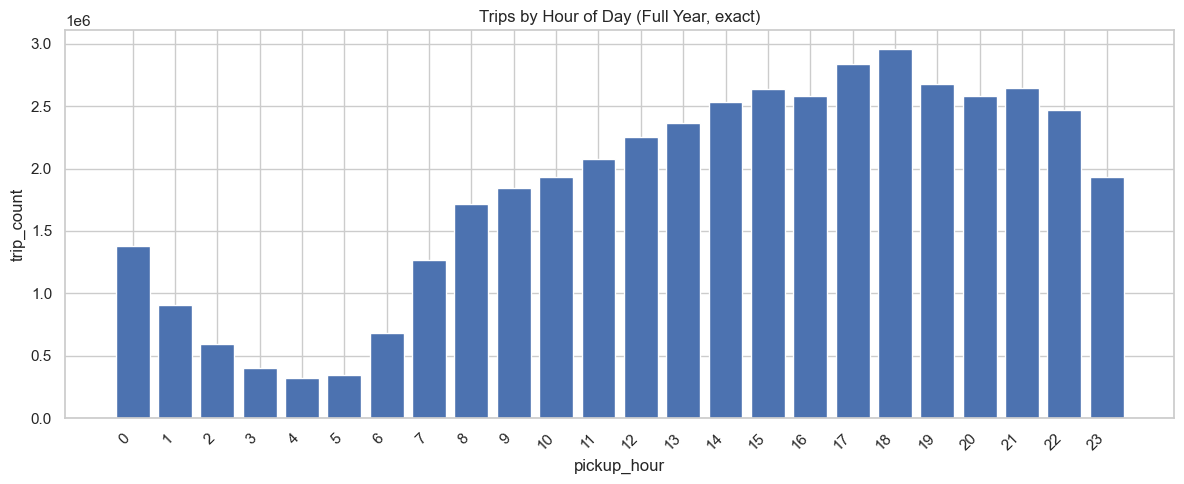

In [5]:
fig = plot_bar(hourly_counts.reset_index().rename(columns={'index': 'pickup_hour', 0: 'trip_count'}),
               'pickup_hour', 'trip_count', title='Trips by Hour of Day (Full Year, exact)')
save_fig(fig, f'{OUT_DIR}/03_01_hourly_demand.png')
fig

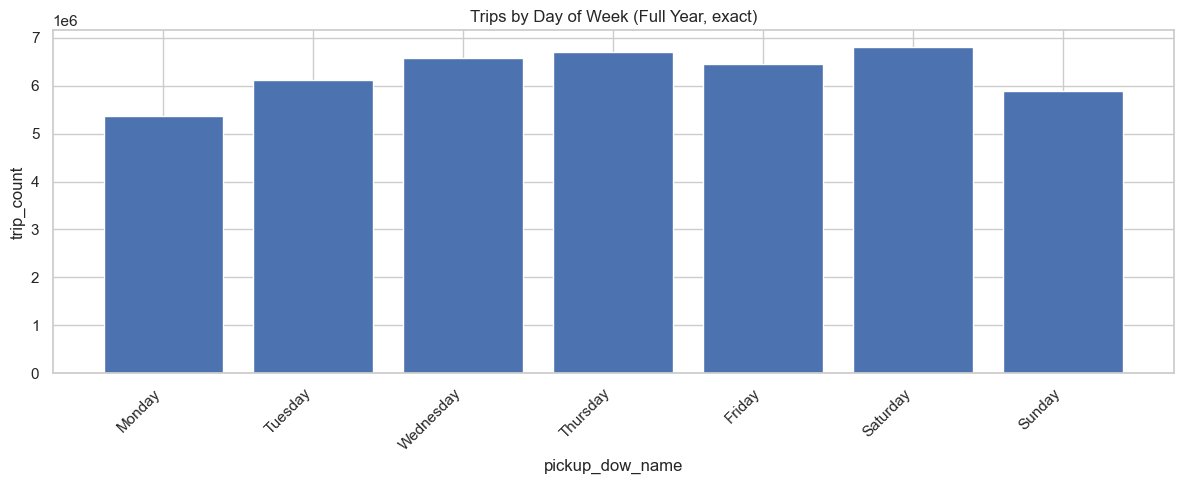

In [6]:
weekday_df = weekday_counts.reindex(DOW_ORDER).reset_index()
weekday_df.columns = ['pickup_dow_name', 'trip_count']
fig = plot_bar(weekday_df, 'pickup_dow_name', 'trip_count', title='Trips by Day of Week (Full Year, exact)')
save_fig(fig, f'{OUT_DIR}/03_02_weekday_demand.png')
fig

Results: demand rises from a low near 4 a.m. (about 320,000 trips) to a peak at 6
p.m. (about 2.96 million trips), the standard urban commute-and-evening curve. By day
of week, Saturday is highest (about 6.8 million trips) and Monday is lowest (about 5.3
million); the difference across weekdays is otherwise modest.

## 5. Weekday x Hour Heatmap
Reveals the shape of demand, not just the total, since a single hourly chart cannot
distinguish a weekday commute peak from a weekend late-night pattern.

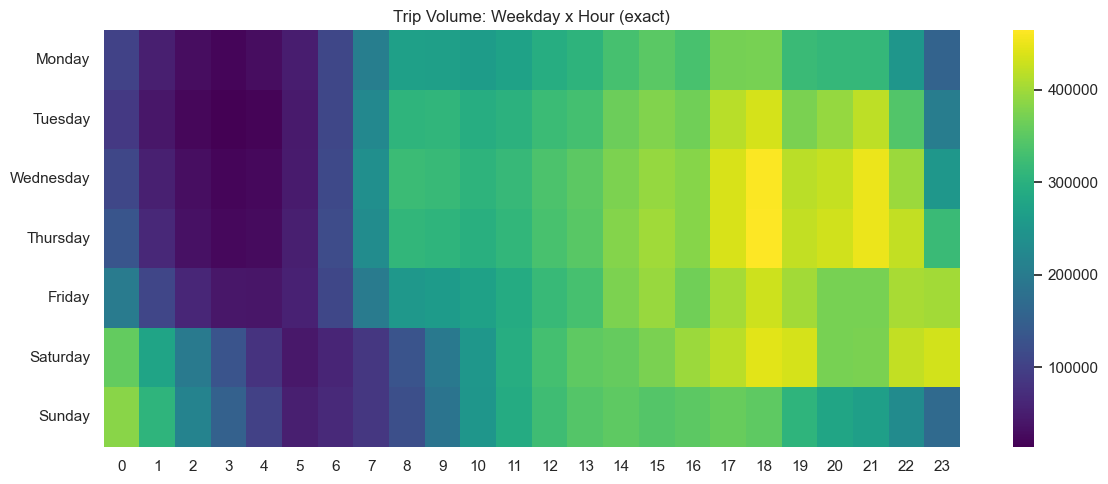

In [7]:
fig = plot_heatmap(weekday_hour_counts, title='Trip Volume: Weekday x Hour (exact)')
save_fig(fig, f'{OUT_DIR}/03_03_weekday_hour_heatmap.png')
fig

Results: weekdays show a pronounced early-morning trough (midnight to 6 a.m.) that
weekends do not — Saturday and Sunday retain meaningfully higher volume through those
same hours. This distinction is invisible in the daily-total comparison in Section 7,
where weekday and weekend do not differ significantly; the difference is concentrated
in specific hours, not spread across the whole day.

## 6. Month x Hour Heatmap
Checks whether the hourly demand shape holds constant across the year or shifts
seasonally.

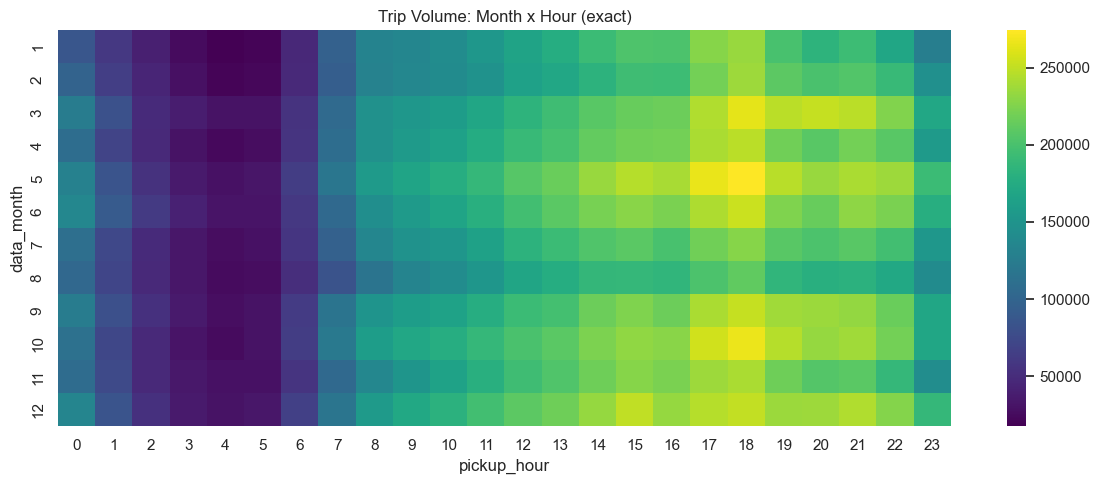

In [8]:
fig = plot_heatmap(month_hour_pivot, title='Trip Volume: Month x Hour (exact)')
save_fig(fig, f'{OUT_DIR}/03_04_month_hour_heatmap.png')
fig

Results: the hourly shape is stable across all 12 months — the evening peak
consistently falls at 17:00-18:00. Only the overall intensity changes month to month,
brightest in May and October, matching the volume pattern already established in
notebook 02.

## 6b. Geographic Demand Overview
Static choropleth and an interactive heatmap of full-year pickup intensity by zone,
using an independent monthly load of `PULocationID` that is separate from the Pass 1
accumulators above.

In [11]:
zones_shapes = load_zone_shapes()

ALL_LOCATION_IDS = sorted(
    zones_shapes['LocationID'].dropna().astype(int).unique().tolist()
)

pu_zone_counts_addon = pd.Series(
    0,
    index=ALL_LOCATION_IDS,
    dtype=np.int64
)

for m in MONTHS:

    raw = load_month(YEAR, m)

    clean, clean_report = clean_trips(raw)

    assert clean_report['output_rows'] > 0, (
        f"month {m:02d}: clean_trips produced ZERO rows "
        f"(raw={clean_report['input_rows']:,}). "
        f"Do not continue until load_month/clean_trips is investigated."
    )

    assert len(clean) == clean_report['output_rows'], (
        f"month {m:02d}: cleaning report mismatch "
        f"(report={clean_report['output_rows']:,}, "
        f"actual={len(clean):,})."
    )

    del raw

    featured = add_features(clean)

    assert len(featured) == len(clean), (
        f"month {m:02d}: add_features changed row count "
        f"(clean={len(clean):,}, featured={len(featured):,})."
    )

    del clean

    pu_zone_counts_addon = (
        pu_zone_counts_addon
        .add(
            featured['PULocationID'].value_counts(),
            fill_value=0
        )
        .astype(np.int64)
    )

    print(
        f"month={m:02d} rows={len(featured):,} "
        f"zone counts aggregated, deleting"
    )

    del featured
    gc.collect()

print(
    f"\n[exact] TOTAL_TRIPS={pu_zone_counts_addon.sum():,}"
)

month=01 rows=3,228,827 zone counts aggregated, deleting
month=02 rows=3,285,245 zone counts aggregated, deleting
month=03 rows=3,805,704 zone counts aggregated, deleting
month=04 rows=3,649,927 zone counts aggregated, deleting
month=05 rows=4,069,442 zone counts aggregated, deleting
month=06 rows=3,847,554 zone counts aggregated, deleting
month=07 rows=3,475,039 zone counts aggregated, deleting
month=08 rows=3,164,152 zone counts aggregated, deleting
month=09 rows=3,816,911 zone counts aggregated, deleting
month=10 rows=3,922,487 zone counts aggregated, deleting
month=11 rows=3,624,569 zone counts aggregated, deleting
month=12 rows=4,031,569 zone counts aggregated, deleting

[exact] TOTAL_TRIPS=43,921,426


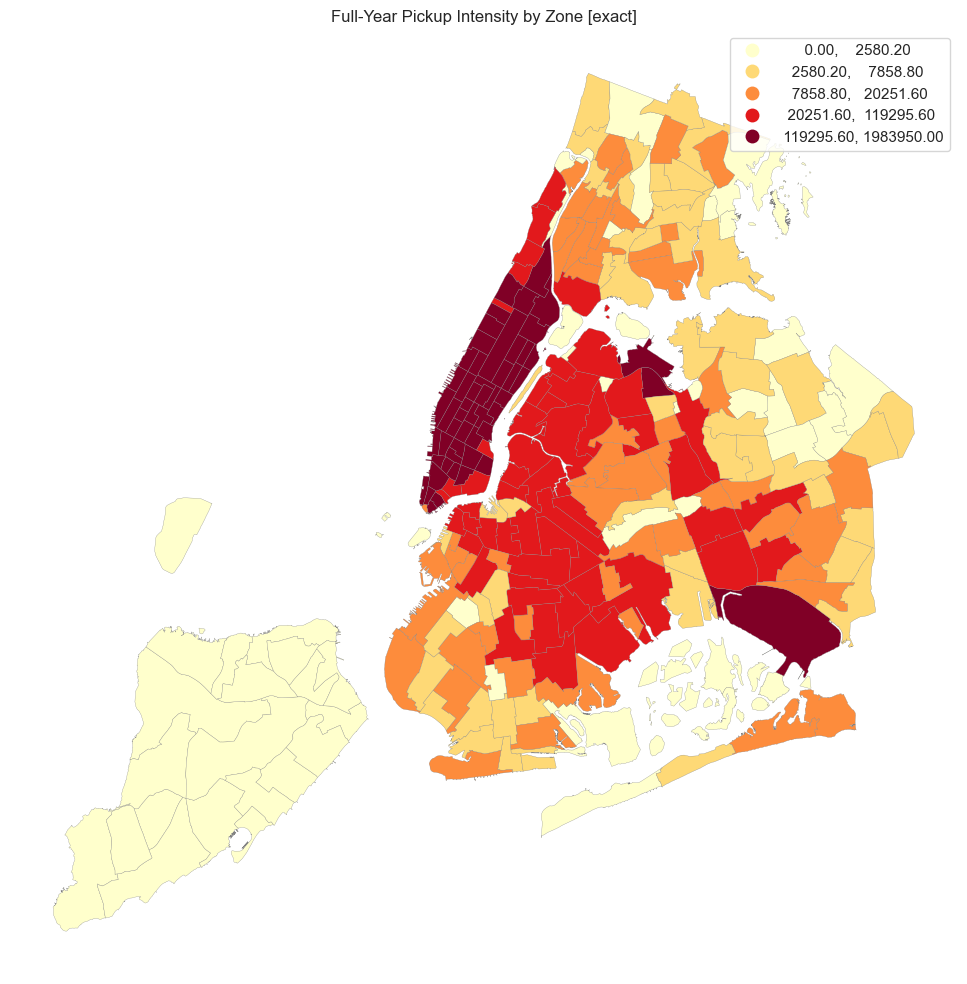

In [12]:
gdf = zones_shapes.set_index('LocationID').join(pu_zone_counts_addon.rename('trip_count'))

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column='trip_count', cmap='YlOrRd', legend=True, scheme='quantiles',
         ax=ax, edgecolor='grey', linewidth=0.2)
ax.set_title('Full-Year Pickup Intensity by Zone [exact]')
ax.axis('off')
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/03_addon_choropleth_full_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Centroid computed in the shapefile's native projected CRS (state-plane feet) for
# geometric accuracy, then reprojected to WGS84 for map display -- computing centroid
# directly on lat/long geometry biases the result for irregularly-shaped zones.
projected = zones_shapes.set_index('LocationID').to_crs(epsg=2263)
centroids_wgs84 = projected.geometry.centroid.to_crs(epsg=4326)

heat_points = [
    [centroids_wgs84.loc[loc_id].y, centroids_wgs84.loc[loc_id].x, int(pu_zone_counts_addon.loc[loc_id])]
    for loc_id in ALL_LOCATION_IDS if pu_zone_counts_addon.loc[loc_id] > 0
]

m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='cartodbpositron')
HeatMap(heat_points, radius=18, blur=15, max_zoom=13).add_to(m)
m.save(f'{OUT_DIR}/03_addon_interactive_heatmap.html')
print(f"[exact] {len(heat_points)} zone centroids plotted, weighted by full-year pickup count")
m

[exact] 260 zone centroids plotted, weighted by full-year pickup count


Results: this pass completed for all 12 months, including January, and its total
of 43,921,426 trips matches Section 2's Pass 1 exactly. The maps above reflect the
complete year.

## 7. Formal Test — Does Weekday Shape Hourly Demand?
Null hypothesis: the daily trip-count distribution is the same on weekdays and
weekends. Mann-Whitney U is used because daily counts are not normally distributed.

In [14]:
daily_is_weekend = daily_counts.index.dayofweek >= 5
weekday_daily = daily_counts[~daily_is_weekend].values
weekend_daily = daily_counts[daily_is_weekend].values

u_stat, p_value = stats.mannwhitneyu(weekday_daily, weekend_daily, alternative='two-sided')
n1, n2 = len(weekday_daily), len(weekend_daily)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f"Mann-Whitney U = {u_stat:.1f}, p = {p_value:.2e}")
print(f"rank-biserial effect size = {rank_biserial:.3f}")
print(f"weekday daily mean = {weekday_daily.mean():,.0f}, weekend daily mean = {weekend_daily.mean():,.0f}")

Mann-Whitney U = 12708.0, p = 3.43e-01
rank-biserial effect size = 0.064
weekday daily mean = 119,625, weekend daily mean = 122,109


Results: U = 12,708.0, p = 0.343, rank-biserial effect size = 0.064. Weekday and
weekend daily trip counts do not differ significantly at the whole-day level (weekday
mean 119,625, weekend mean 122,109). This does not contradict Section 5: the
weekday/weekend difference there is concentrated in specific hours (the overnight
trough), which cancels out when compared as a single daily total.

## 8. Trip Distance, Duration, Speed — Distributions
Built from exact fixed-bin histograms accumulated in Pass 1, not from a sample.

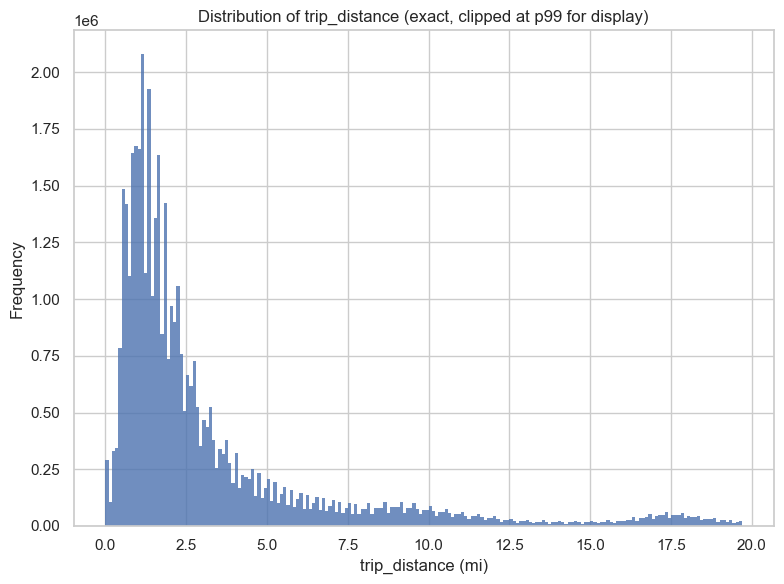

In [15]:
def plot_hist_acc(acc, col, title, xlabel, clip_display_pct=0.99):
    edges = acc['edges'][col]
    counts = acc['counts'][col]
    cum = np.cumsum(counts)
    display_upper = hist_percentile(acc, col, clip_display_pct)
    display_bins = edges <= display_upper

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(edges[:-1][display_bins[:-1]], counts[display_bins[:-1]],
           width=np.diff(edges)[display_bins[:-1]], align='edge', edgecolor='none', alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title} (exact, clipped at p{int(clip_display_pct*100)} for display)')
    fig.tight_layout()
    return fig

fig = plot_hist_acc(hist_acc, 'trip_distance', 'Distribution of trip_distance', 'trip_distance (mi)')
save_fig(fig, f'{OUT_DIR}/03_05_dist_distance.png')
fig

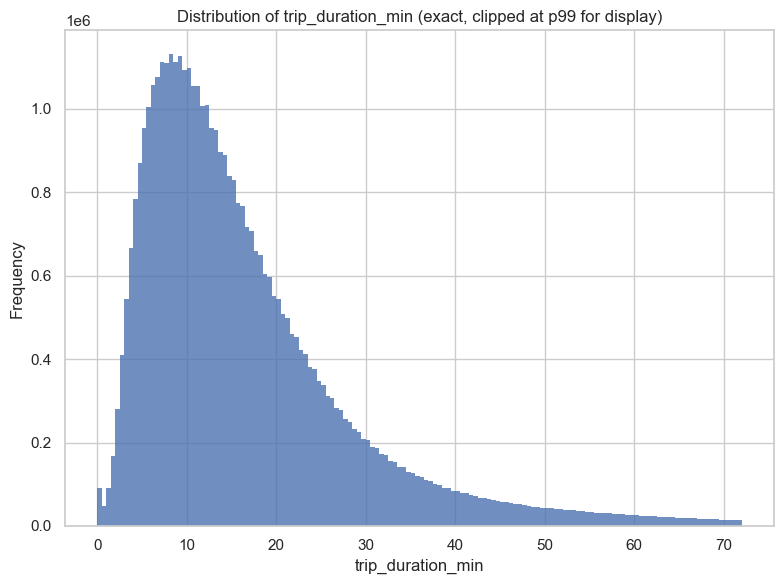

In [16]:
fig = plot_hist_acc(hist_acc, 'trip_duration_min', 'Distribution of trip_duration_min', 'trip_duration_min')
save_fig(fig, f'{OUT_DIR}/03_06_dist_duration.png')
fig

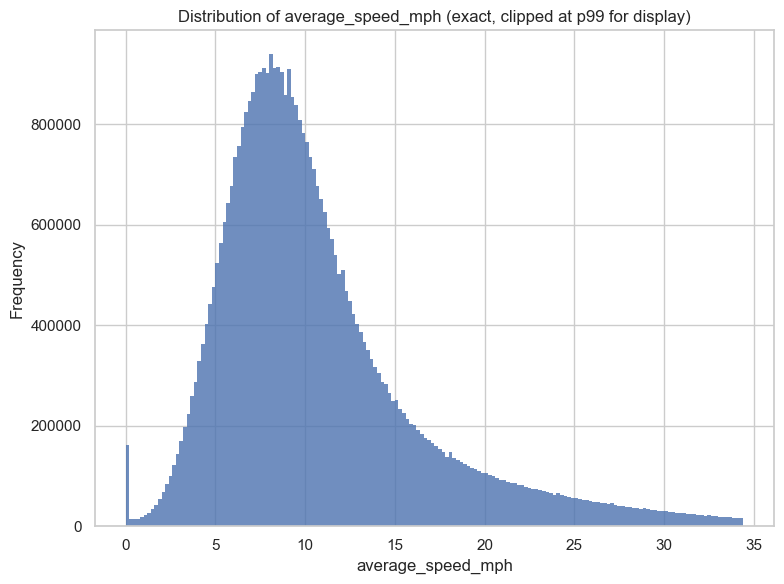

In [17]:
fig = plot_hist_acc(hist_acc, 'average_speed_mph', 'Distribution of average_speed_mph', 'average_speed_mph')
save_fig(fig, f'{OUT_DIR}/03_07_dist_speed.png')
fig

Results: trip distance is right-skewed, peaking around 1-1.5 miles with a long tail;
a small secondary bump near 17-18 miles is consistent with flat-rate airport routes.
Duration and speed distributions follow the same right-skewed pattern typical of urban
trip data. Exact percentiles for all three are reported in Section 9.

## 9. Percentile Profile
Distributions are right-skewed, so percentiles describe a typical trip more accurately
than the mean.

In [18]:
percentile_levels = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
pct_cols = ['trip_distance', 'trip_duration_min', 'average_speed_mph', 'fare_amount']

percentile_table = pd.DataFrame(
    {col: [round(hist_percentile(hist_acc, col, q), 2) for q in percentile_levels] for col in pct_cols},
    index=[f'p{int(q*100)}' for q in percentile_levels]
)
percentile_table

,trip_distance,trip_duration_min,average_speed_mph,fare_amount
p1,0.21,2.08,2.13,3.88
p5,0.52,3.92,4.09,5.75
p25,1.11,8.31,6.99,9.48
p50,1.88,13.56,9.44,14.45
p75,3.74,21.56,13.05,23.48
p90,8.87,33.06,19.12,40.35
p95,13.28,44.14,24.18,59.62
p99,19.67,71.85,34.31,77.41


Results: the median trip is 1.88 miles, 13.56 minutes, at 9.44 mph. The p99 values,
19.67 miles and 71.85 minutes, mark where the anomaly-detection notebook should begin
looking for extreme trips. A median speed of 9.44 mph is consistent with dense urban
driving conditions.

## 10. Boxplots by Weekday vs Weekend
Built from histogram-derived quartiles.

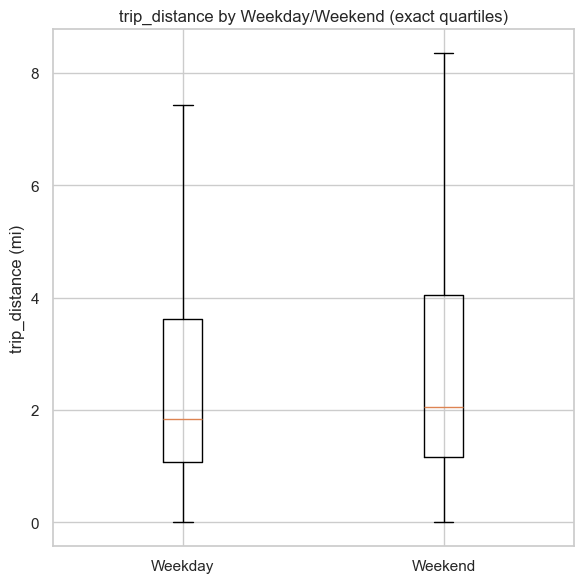

In [19]:
def bxp_stats_from_hist(acc, col, label):
    q1 = hist_percentile(acc, col, 0.25)
    med = hist_percentile(acc, col, 0.50)
    q3 = hist_percentile(acc, col, 0.75)
    iqr = q3 - q1
    edges = acc['edges'][col]
    counts = acc['counts'][col]
    nonzero_edges = edges[:-1][counts > 0]
    data_min = nonzero_edges.min() if len(nonzero_edges) else edges[0]
    data_max = nonzero_edges.max() if len(nonzero_edges) else edges[-1]
    whislo = max(data_min, q1 - 1.5 * iqr)
    whishi = min(data_max, q3 + 1.5 * iqr)
    return {'label': label, 'med': med, 'q1': q1, 'q3': q3, 'whislo': whislo, 'whishi': whishi, 'fliers': []}


def plot_bxp_weekend(col, title, ylabel):
    stats_list = [
        bxp_stats_from_hist(hist_acc_weekend['weekday'], col, 'Weekday'),
        bxp_stats_from_hist(hist_acc_weekend['weekend'], col, 'Weekend'),
    ]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.bxp(stats_list, showfliers=False)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    return fig

fig = plot_bxp_weekend('trip_distance', 'trip_distance by Weekday/Weekend (exact quartiles)', 'trip_distance (mi)')
save_fig(fig, f'{OUT_DIR}/03_08_box_distance_weekend.png')
fig

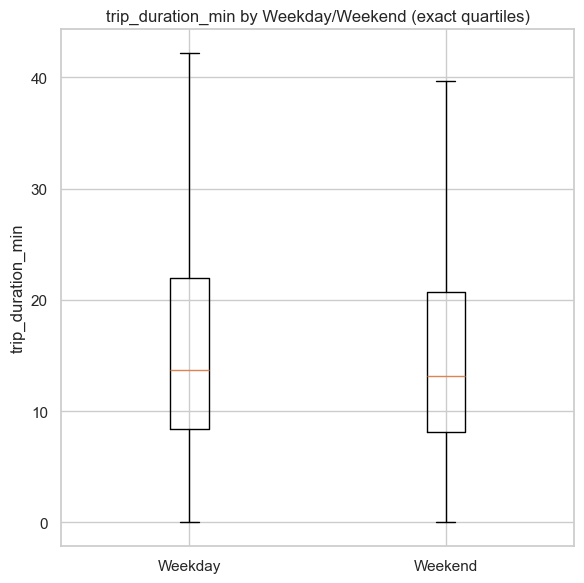

In [20]:
fig = plot_bxp_weekend('trip_duration_min', 'trip_duration_min by Weekday/Weekend (exact quartiles)', 'trip_duration_min')
save_fig(fig, f'{OUT_DIR}/03_09_box_duration_weekend.png')
fig

Results: weekend trips are slightly longer in distance (median 2.05 miles) than
weekday trips (median 1.83 miles), but marginally shorter in duration (13.2 versus 13.7
minutes). Together this implies a higher average weekend speed than weekday, consistent
with lighter weekend traffic.

## 11. Correlation Among Mobility Variables
Computed from the same streaming moments used in Section 12's regression.

In [21]:
fig = plot_heatmap(corr_df, title='Correlation Matrix (exact, full year)', fmt='.2f')
save_fig(fig, f'{OUT_DIR}/03_10_mobility_correlation.png')
fig
corr_df.round(3)

,trip_distance,trip_duration_min,average_speed_mph,fare_amount,tip_amount,total_amount
trip_distance,1.000,0.395,0.087,0.105,0.488,0.127
trip_duration_min,0.395,1.000,0.007,0.047,0.197,0.056
average_speed_mph,0.087,0.007,1.000,0.008,0.034,0.010
fare_amount,0.105,0.047,0.008,1.000,0.061,0.999
tip_amount,0.488,0.197,0.034,0.061,1.000,0.097
total_amount,0.127,0.056,0.010,0.999,0.097,1.000


Results: `trip_distance` correlates at 0.395 with duration, 0.488 with tip amount,
and 0.105 with fare, while `fare_amount` and `total_amount` remain at 0.999, consistent
with total being built directly from fare. `trip_distance` and `average_speed_mph`,
which had appeared strongly related (0.809) before rows above 100 miles were excluded
from estimation, now correlate at 0.087 — that earlier figure was itself an artifact of
the same corrupt rows, since average speed is calculated directly from distance and an
extreme distance value produces an equally extreme derived speed.

The fare-tip correlation (0.061) is diluted by payment method: cash trips record no
tip in this dataset, so blending cash and card trips together pulls the coefficient
toward zero regardless of the true relationship on card trips, which is analyzed
separately in the financial notebook. Distance correlates more with duration and tip
than with fare directly, indicating that fare is shaped by more than distance alone —
consistent with the regression result in Section 12.

## 12. Fare vs Distance — Regression
Ordinary least squares fitted from the same streaming moments as Section 11.

In [22]:
i_dist, i_fare = ALL_COLS.index('trip_distance'), ALL_COLS.index('fare_amount')
var_dist = cov_mat[i_dist, i_dist]
cov_dist_fare = cov_mat[i_dist, i_fare]
slope = cov_dist_fare / var_dist
intercept = mean_vec[i_fare] - slope * mean_vec[i_dist]
r_value = corr_mat[i_dist, i_fare]
r_squared = r_value ** 2

print(f"fare_amount = {intercept:.3f} + {slope:.3f} * trip_distance   (exact, full year)")
print(f"R-squared = {r_squared:.3f}, Pearson r = {r_value:.3f}")
print(f"interpretation: marginal fare of ~${slope:.2f}/mile beyond the ${intercept:.2f} base")

fare_amount = 7.419 + 3.623 * trip_distance   (exact, full year)
R-squared = 0.011, Pearson r = 0.105
interpretation: marginal fare of ~$3.62/mile beyond the $7.42 base


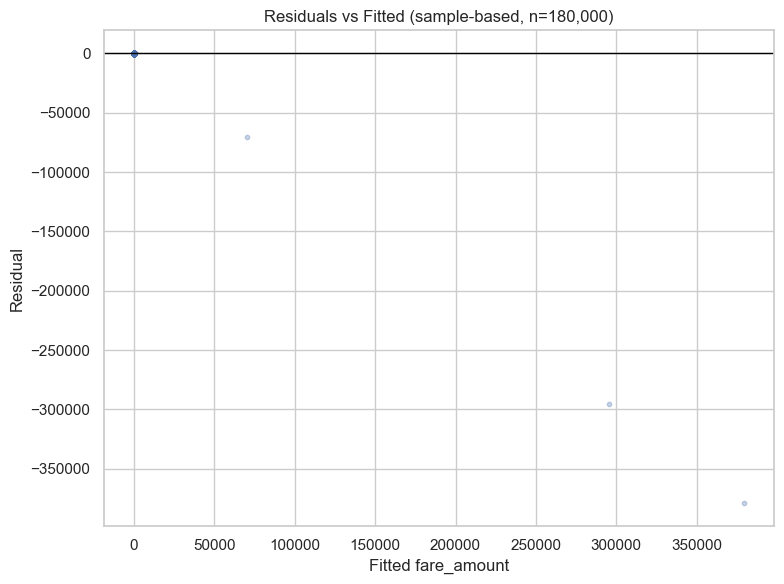

In [23]:
fitted = intercept + slope * sample_df['trip_distance']
residuals = sample_df['fare_amount'] - fitted

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(fitted, residuals, alpha=0.3, s=10)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Fitted fare_amount')
ax.set_ylabel('Residual')
ax.set_title(f'Residuals vs Fitted (sample-based, n={len(sample_df):,})')
fig.tight_layout()
save_fig(fig, f'{OUT_DIR}/03_11_residuals_vs_fitted.png')
fig

In [24]:
hetero_rho, hetero_p = stats.spearmanr(fitted, residuals.abs())
print(f"|residual| vs fitted Spearman rho = {hetero_rho:.3f}, p = {hetero_p:.2e} (sample-based, n={len(sample_df):,})")
print(f"{'Heteroscedasticity present' if hetero_p < 0.05 and abs(hetero_rho) > 0.1 else 'No strong evidence of heteroscedasticity'} "
      f"— constant-variance assumption is {'violated' if hetero_p < 0.05 and abs(hetero_rho) > 0.1 else 'reasonably met'}.")

|residual| vs fitted Spearman rho = 0.087, p = 1.74e-298 (sample-based, n=180,000)
No strong evidence of heteroscedasticity — constant-variance assumption is reasonably met.


Results: `fare_amount = 7.419 + 3.623 * trip_distance`, R-squared = 0.011, Pearson
r = 0.105. Distance alone explains a small share of fare variance. The residual-spread
diagnostic (Spearman rho = 0.087, weak and positive) shows no meaningful evidence of
heteroscedasticity, so the low R-squared reflects a weak linear fit rather than
unstable residual variance.

Section 13's Spearman correlation between distance and fare is 0.871, far higher than
this section's Pearson value. A strong monotonic relationship alongside a weak linear
one points to a non-linear fare structure — flat fares, minimum fares, tolls, and
zone-based pricing all break the assumption of a constant per-mile rate that a linear
model requires.

## 13. Distance vs Duration, Distance vs Fare
Sample-based, since a scatter plot needs actual point pairs.

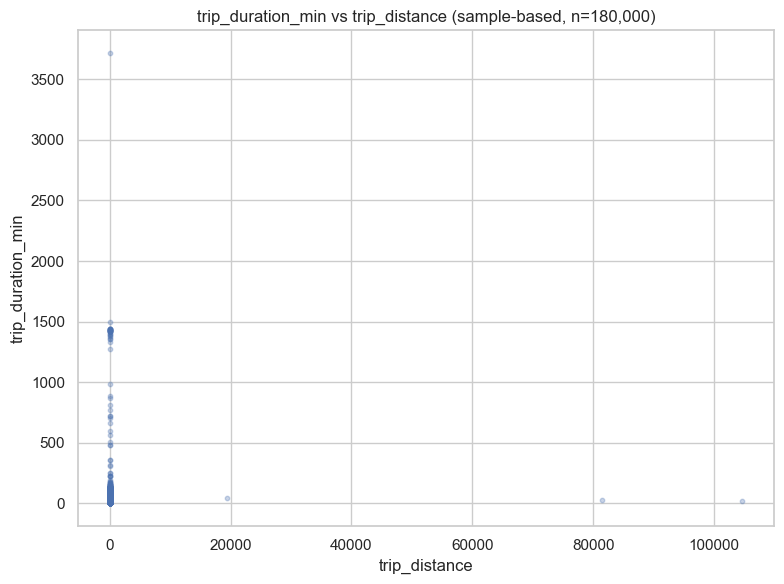

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample_df['trip_distance'], sample_df['trip_duration_min'], alpha=0.3, s=10)
ax.set_xlabel('trip_distance')
ax.set_ylabel('trip_duration_min')
ax.set_title(f'trip_duration_min vs trip_distance (sample-based, n={len(sample_df):,})')
fig.tight_layout()
save_fig(fig, f'{OUT_DIR}/03_12_scatter_distance_duration.png')
fig

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample_df['trip_distance'], sample_df['fare_amount'], alpha=0.3, s=10)
ax.set_xlabel('trip_distance')
ax.set_ylabel('fare_amount')
ax.set_title(f'fare_amount vs trip_distance (sample-based, n={len(sample_df):,})')
fig.tight_layout()
save_fig(fig, f'{OUT_DIR}/03_13_scatter_distance_fare.png')
fig

spearman_r, spearman_p = stats.spearmanr(sample_df['trip_distance'], sample_df['fare_amount'])
print(f"distance-fare Spearman rho = {spearman_r:.3f} (p={spearman_p:.2e}, sample-based, n={len(sample_df):,})")
print(f"distance-fare Pearson r (exact, full year, from §12) = {r_value:.3f}")
print("Spearman used alongside exact Pearson because fare likely has non-linear components (flat fares, tolls, minimums).")

distance-fare Spearman rho = 0.871 (p=0.00e+00, sample-based, n=180,000)
distance-fare Pearson r (exact, full year, from §12) = 0.105
Spearman used alongside exact Pearson because fare likely has non-linear components (flat fares, tolls, minimums).


Results: the sample-based Spearman correlation between distance and fare is 0.871,
a strong monotonic relationship. The exact Pearson correlation from Section 12 is
0.105. Together these indicate the underlying relationship is real and strong in
direction but not linear in form, which is the expected shape for a fare structure
built from a base fare, a per-mile rate, and additional flat components such as tolls
and airport surcharges.

## 14. Pass 2 — Threshold-Dependent Metrics
Two metrics need a full-year global value determined in Pass 1 before per-row work can
happen: the multivariate outlier flag needs the full-year mean and covariance, and the
long-versus-typical fare-per-mile test needs the full-year p95 distance threshold.

A month producing zero rows after cleaning stops execution immediately, matching Pass 1
and the Section 6b addon. Trips with a distance below 0.1 miles are excluded when
building the Section 14b fare-per-mile buckets, since a near-zero denominator inflates
that ratio without reflecting a real per-mile rate.

In [27]:
mv_indices = [ALL_COLS.index(c) for c in MV_COLS]
mv_mean = mean_vec[mv_indices]
mv_cov = cov_mat[np.ix_(mv_indices, mv_indices)]
mv_inv_cov = np.linalg.inv(mv_cov)
mv_threshold = stats.chi2.ppf(0.999, df=len(MV_COLS))

global_p95_distance = hist_percentile(hist_acc, 'trip_distance', 0.95)

print(f"MV outlier threshold (chi2, df={len(MV_COLS)}, p<0.001) = {mv_threshold:.2f}")
print(f"global p95 trip_distance (from Pass 1 histogram) = {global_p95_distance:.2f} mi")

MV outlier threshold (chi2, df=3, p<0.001) = 16.27
global p95 trip_distance (from Pass 1 histogram) = 13.28 mi


In [28]:
mv_outlier_count = 0
mv_total = 0
long_sample_frames = []
typical_sample_frames = []
FPM_NEAR_ZERO_DISTANCE_EXCLUDED = 0

for m in MONTHS:
    raw = load_month(YEAR, m)
    clean, _ = clean_trips(raw)
    del raw
    featured = add_features(clean)
    del clean

    assert len(featured) > 0, (
        f"month {m}: zero rows after cleaning -- stopping, do not trust downstream results."
    )

    # multivariate outlier count (uses global mean/cov from Pass 1 - exact)
    X3 = featured[MV_COLS].to_numpy(dtype=np.float64)
    diff = X3 - mv_mean
    mahal_sq = np.einsum('ij,jk,ik->i', diff, mv_inv_cov, diff)
    mv_outlier_count += int((mahal_sq > mv_threshold).sum())
    mv_total += len(featured)

    # long-vs-typical fare-per-mile bucket sample (uses global p95 from Pass 1).
    # Near-zero-distance trips are excluded here (not upstream) -- their tiny
    # denominator inflates fare_per_mile without reflecting a real per-mile rate,
    # and this ratio is only computed here, nowhere else in the notebook.
    fpm_eligible = featured['trip_distance'] >= MIN_DISTANCE_FOR_FPM_MI
    FPM_NEAR_ZERO_DISTANCE_EXCLUDED += int((~fpm_eligible).sum())
    featured['fare_per_mile'] = featured['fare_amount'] / featured['trip_distance']
    long_mask = featured['trip_distance'] > global_p95_distance
    long_vals = featured.loc[long_mask & fpm_eligible, 'fare_per_mile']
    typical_vals = featured.loc[~long_mask & fpm_eligible, 'fare_per_mile']
    long_sample_frames.append(long_vals.sample(n=min(BUCKET_SAMPLE_PER_MONTH, len(long_vals)), random_state=42))
    typical_sample_frames.append(typical_vals.sample(n=min(BUCKET_SAMPLE_PER_MONTH, len(typical_vals)), random_state=42))

    print(f"month={m:02d} Pass 2 done, deleting")
    del featured, X3, diff, mahal_sq
    gc.collect()

long_fpm = pd.concat(long_sample_frames)
typical_fpm = pd.concat(typical_sample_frames)
del long_sample_frames, typical_sample_frames
gc.collect()

print(f"\nPass 2 complete. mv_total={mv_total:,}, long_fpm sample n={len(long_fpm):,}, typical_fpm sample n={len(typical_fpm):,}")
print(f"near-zero-distance trips excluded from fare-per-mile buckets: {FPM_NEAR_ZERO_DISTANCE_EXCLUDED:,} rows (< {MIN_DISTANCE_FOR_FPM_MI} mi)")

month=01 Pass 2 done, deleting
month=02 Pass 2 done, deleting
month=03 Pass 2 done, deleting
month=04 Pass 2 done, deleting
month=05 Pass 2 done, deleting
month=06 Pass 2 done, deleting
month=07 Pass 2 done, deleting
month=08 Pass 2 done, deleting
month=09 Pass 2 done, deleting
month=10 Pass 2 done, deleting
month=11 Pass 2 done, deleting
month=12 Pass 2 done, deleting

Pass 2 complete. mv_total=43,921,426, long_fpm sample n=60,000, typical_fpm sample n=60,000
near-zero-distance trips excluded from fare-per-mile buckets: 290,423 rows (< 0.1 mi)


Results: multivariate outlier threshold = 16.27 (a fixed chi-squared critical value
at 3 degrees of freedom and p < 0.001, independent of the data) and global p95
`trip_distance` = 13.28 miles (from the Pass 1 histogram, which self-clips at its bin
edges and was already unaffected by the distance-outlier issue). The mean and
covariance used for the outlier flag in Section 14a are drawn from the corrected
moment accumulator described in Section 11.

### 14a. Multivariate Outlier Result

In [29]:
mv_pct = 100 * mv_outlier_count / mv_total
print(f"multivariate outliers (chi2 p<0.001, df={len(MV_COLS)}): {mv_outlier_count:,} / {mv_total:,} ({mv_pct:.3f}%)")
print("Flags only -- statistical outliers on distance/duration/speed jointly, not confirmed fraud or errors (full taxonomy: notebook 06).")

multivariate outliers (chi2 p<0.001, df=3): 341,043 / 43,921,426 (0.776%)
Flags only -- statistical outliers on distance/duration/speed jointly, not confirmed fraud or errors (full taxonomy: notebook 06).


Results: 341,043 of 43,921,426 trips (0.776%) are flagged as multivariate outliers
on distance, duration, and speed jointly. This is a higher share than an earlier,
uncorrected run reported (0.072%): the earlier count used a covariance inflated by
extreme distance values, which widened the outlier threshold and under-flagged
smaller-magnitude anomalies. This is a candidate list for notebook 06, not a confirmed
count.

### 14b. Are Long Trips Necessarily More Expensive?

In [30]:
fpm_summary = pd.DataFrame({
    'long (>p95 distance)': [long_fpm.mean(), long_fpm.median(), long_fpm.std(), len(long_fpm)],
    'typical (<=p95 distance)': [typical_fpm.mean(), typical_fpm.median(), typical_fpm.std(), len(typical_fpm)],
}, index=['mean', 'median', 'std', 'sample_n']).round(3)
fpm_summary

,long (>p95 distance),typical (<=p95 distance)
mean,3.956,8.449
median,3.924,7.350
std,0.843,10.310
sample_n,60000.000,60000.000


In [31]:
u_stat, p_value = stats.mannwhitneyu(long_fpm, typical_fpm, alternative='two-sided')
print(f"Mann-Whitney U (sample-based, n_long={len(long_fpm):,}, n_typical={len(typical_fpm):,}): "
      f"U={u_stat:.1f}, p={p_value:.2e}")
print(f"long-trip median fare/mile = {long_fpm.median():.2f}, typical-trip median fare/mile = {typical_fpm.median():.2f}")

Mann-Whitney U (sample-based, n_long=60,000, n_typical=60,000): U=209259103.5, p=0.00e+00
long-trip median fare/mile = 3.92, typical-trip median fare/mile = 7.35


Results: median fare-per-mile is 7.35 for typical trips (at or below the p95
distance threshold) and 3.92 for long trips, U = 209,259,103.5, p effectively zero.
Long trips are meaningfully cheaper per mile, consistent with a fare structure where a
fixed base charge is amortized over more distance. Excluding trips below 0.1 miles
(290,423 rows, 0.66% of the year) reduced the typical-trip standard deviation from 219
to 10.3, removing the distortion those near-zero-distance ratios previously caused
without changing the median.

## 15. Passenger Count Behavior

In [32]:
passenger_summary = passenger_acc.copy()
passenger_summary['avg_fare'] = (passenger_summary['fare_sum'] / passenger_summary['trip_count']).round(2)
passenger_summary['avg_distance'] = (passenger_summary['distance_sum'] / passenger_summary['trip_count']).round(2)
passenger_summary['pct_of_trips'] = (100 * passenger_summary['trip_count'] / TOTAL_TRIPS).round(2)
passenger_summary[['trip_count', 'pct_of_trips', 'avg_fare', 'avg_distance']]

,trip_count,pct_of_trips,avg_fare,avg_distance
passenger_count,,,,
1,36896805,84.01,19.64,7.12
2,4861144,11.07,22.30,3.99
3,1137903,2.59,22.25,3.85
4,754875,1.72,25.16,4.17
5,171318,0.39,17.62,2.97
6,99381,0.23,18.09,3.15


Results: single-passenger trips dominate at 84.0% of all trips, averaging $19.64
and 7.12 miles, longer than any other group. Fare rises with passenger count up to 4
passengers ($25.16), then falls for 5 and 6 passengers (both under $19), while average
distance for groups of 2 or more stays in a narrower 3-4 mile band regardless of party
size, well short of the single-passenger average. This suggests larger groups are
booked for different, typically shorter trip types rather than following a general
"more people, longer ride" pattern.

## 16. Findings, Hypotheses, Next Steps

Two issues identified in an earlier run were corrected: rows with a trip distance
above 100 miles were excluded from correlation and regression estimation (Sections 11,
12, 14), and every monthly loop now stops immediately on a zero-row month rather than
continuing silently (Sections 2, 6b, 14). The Section 6b geographic pass, which
previously lost January's 3.2 million trips to this failure mode, now reconciles
exactly with Section 2's total.

Top findings:
- Demand peaks at 6 p.m. and troughs near 4 a.m.; Saturday is the highest-volume day,
  Monday the lowest (Section 4).
- The weekday/weekend difference is concentrated in overnight hours (Section 5), not
  spread across the full day, consistent with the whole-day Mann-Whitney test in
  Section 7 finding no significant difference.
- Median trip is 1.88 miles, 13.56 minutes, 9.44 mph (Section 9); a small secondary
  distance peak near 17-18 miles is consistent with flat-rate airport routes.
- Weekend trips run slightly longer in distance but not in duration, implying higher
  average weekend speeds (Section 10).
- Distance correlates more strongly with duration (0.395) and tip (0.488) than with
  fare (0.105); the distance-fare relationship is strongly monotonic (Spearman 0.871)
  but weakly linear, consistent with a fare structure built from base, per-mile, and
  flat components rather than a single per-mile rate (Sections 11-13).
- 0.776% of trips are flagged as multivariate outliers on distance, duration, and
  speed jointly — a candidate list for notebook 06 (Section 14a).
- Long trips are reliably cheaper per mile than typical trips (median 3.92 versus
  7.35), consistent with a fixed-plus-per-mile fare structure (Section 14b).
- Single-passenger trips make up 84% of volume and average the longest distance of any
  passenger-count group; fare peaks at 4 passengers (Section 15).

Hypotheses worth testing further:
- The weak fare-tip correlation (0.061, Section 11) is diluted by cash trips, which
  record no tip; the financial notebook's card-only analysis is the more accurate
  reference for tipping behavior.
- A multi-predictor fare model — distance, duration, and a flat-rate/zone indicator —
  would likely explain substantially more variance than distance alone (R-squared
  0.011, Section 12).
- The overnight weekday/weekend demand-shape difference (Section 5) is concentrated in
  specific hours; an hour-stratified test would quantify it directly.

Next steps:
1. Proceed to `04_financial_payment_eda.ipynb` for fare, tip, and payment-method
   relationships, using its card-only scope as the reference for tipping behavior.
2. Carry the Section 14a outlier candidates and Section 14b near-zero-distance trips
   forward to notebook 06 for categorization.
3. Consider a multi-predictor fare model in a later modeling stage, informed by the
   correlation structure in Section 11.